                     Temp_Celsius
2024-05-01 00:00:00     22.198686
2024-05-01 00:30:00     21.962605
2024-05-01 01:00:00     23.071353
2024-05-01 01:30:00     23.439400
2024-05-01 02:00:00     23.477980

--- ADF TEST ---
ADF Statistic: -1.6196251282105991
p-value: 0.4729258343759564
Non-Stationary Data

First 5 Rows:
                      Observed  Trend  Seasonal  Residual
2024-05-01 00:00:00  22.198686    NaN  0.033915       NaN
2024-05-01 00:30:00  21.962605    NaN -0.187892       NaN
2024-05-01 01:00:00  23.071353    NaN  0.737413       NaN
2024-05-01 01:30:00  23.439400    NaN  0.686330       NaN
2024-05-01 02:00:00  23.477980    NaN  1.205108       NaN


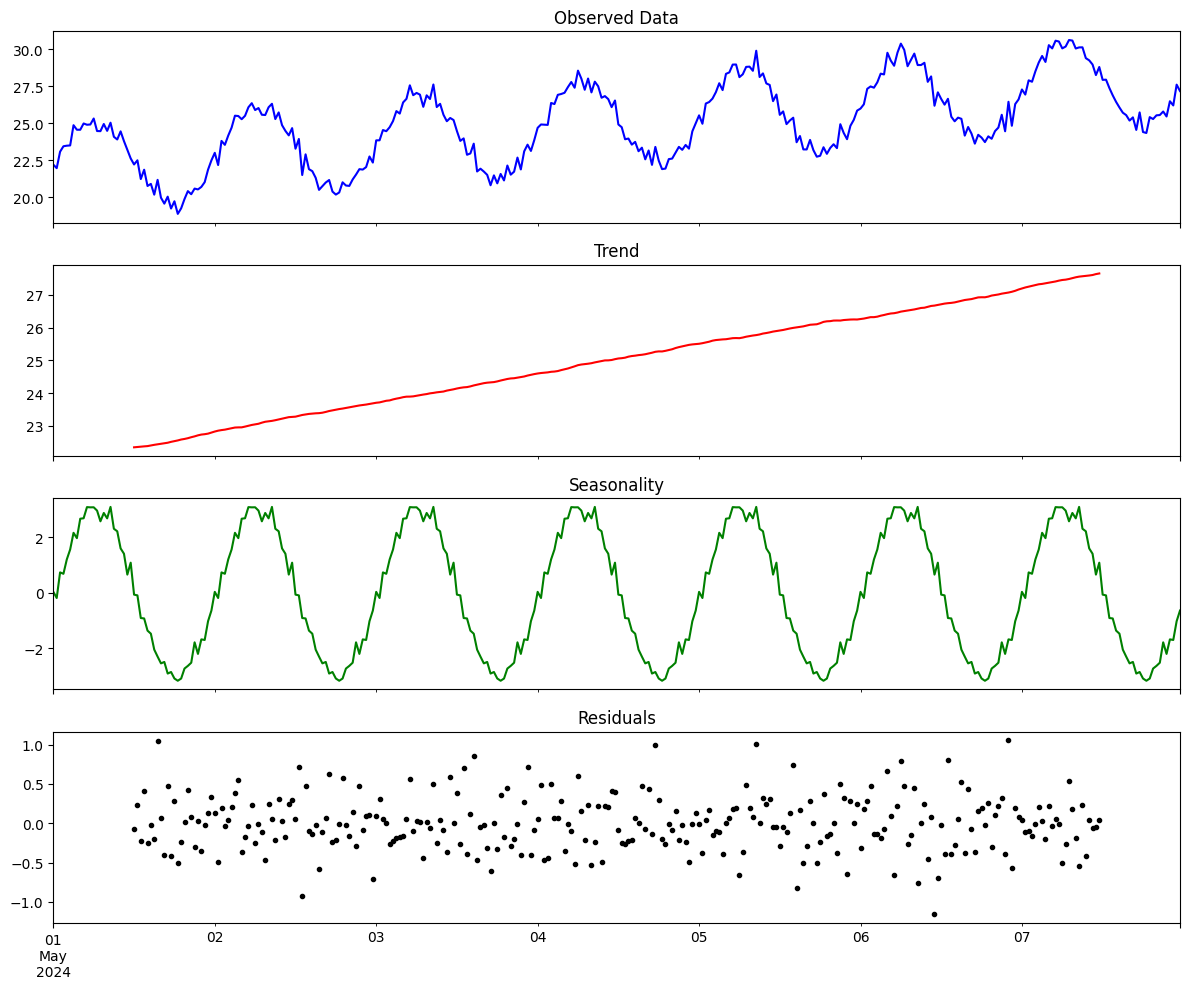

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# STEP 1: Create Time Dataset


np.random.seed(42)

# 7 days data (30 min interval)
time_index = pd.date_range(
    start='2024-05-01',
    periods=336,
    freq='30min'
)

# Trend component
trend = np.linspace(22, 28, 336)

# Seasonal component
seasonal = 3 * np.sin(2 * np.pi * time_index.hour / 24)

# Noise component
noise = np.random.normal(0, 0.4, 336)

# Final sensor values
sensor_values = trend + seasonal + noise

# Create DataFrame
df = pd.DataFrame(
    {'Temp_Celsius': sensor_values},
    index=time_index
)

print(df.head())


# STEP 2: Stationarity Test

print("\n--- ADF TEST ---")

result = adfuller(df['Temp_Celsius'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("Stationary Data")
else:
    print("Non-Stationary Data")


# STEP 3: Time Series Decomposition

decomposition = seasonal_decompose(
    df['Temp_Celsius'],
    model='additive',
    period=48
)

# Create Component Table
df_components = pd.DataFrame({
    'Observed': decomposition.observed,
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
})

print("\nFirst 5 Rows:")
print(df_components.head())


# STEP 4: Visualization

fig, axes = plt.subplots(4, 1, figsize=(12,10), sharex=True)

# Observed
df_components['Observed'].plot(
    ax=axes[0],
    color='blue',
    title='Observed Data'
)

# Trend
df_components['Trend'].plot(
    ax=axes[1],
    color='red',
    title='Trend'
)

# Seasonal
df_components['Seasonal'].plot(
    ax=axes[2],
    color='green',
    title='Seasonality'
)

# Residual
df_components['Residual'].plot(
    ax=axes[3],
    color='black',
    style='.',
    title='Residuals'
)

plt.tight_layout()
plt.show()